In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import zscore
import numpy as np
import math
import ast
import pickle

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense
from keras_tuner.tuners import RandomSearch
from tensorflow.keras import layers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

In [156]:
flight = pd.read_csv('data/2019-USA-data/05-2019.csv')

In [157]:
# remove all the canceled flights
filtered_flight = flight[flight['cancelled_code'] == 'N']

In [158]:

# remove flights don't have weather data
columns_to_check = [
    'HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x', 'HourlyStationPressure_x',
    'HourlyVisibility_x', 'HourlyWindSpeed_x', 'HourlyDryBulbTemperature_y',
    'HourlyPrecipitation_y', 'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y'
]

# Check for empty values in the specified columns
empty_values = filtered_flight[columns_to_check].isnull().sum()

# Display the result
print(empty_values)

filtered_flight = filtered_flight.dropna(subset=columns_to_check)

HourlyDryBulbTemperature_x     258
HourlyPrecipitation_x         1273
HourlyStationPressure_x        258
HourlyVisibility_x             258
HourlyWindSpeed_x              258
HourlyDryBulbTemperature_y     258
HourlyPrecipitation_y         1276
HourlyStationPressure_y        258
HourlyVisibility_y             258
HourlyWindSpeed_y              258
dtype: int64


In [159]:
# remove column: date, cancelled_code, STATION_x, STATION_y 
# Specify the columns to remove
columns_to_remove = ['year', 'month', 'day', 'weekday', 'cancelled_code', 'STATION_x', 'STATION_y']

# Drop the specified columns
filtered_flight.drop(columns=columns_to_remove, inplace=True)

In [160]:
def strsum(str_list):
    result = ''
    for item in str_list:
        if pd.isnull(item):
            pass
        else:
            result += item
    if result == '':
        result = np.nan
    return result

filtered_flight['airport_time_flight'] = list(zip(filtered_flight['origin_airport'], 
                                                  filtered_flight['scheduled_departure_dt'], filtered_flight['flight_number']))
merge_data_group = filtered_flight.groupby('airport_time_flight')

filtered_flight['y'] = (filtered_flight['departure_delay'] >= 30) | (filtered_flight['arrival_delay'] >= 30)

merge_data_group_df = pd.DataFrame([])

merge_data_group_data_airline = merge_data_group['carrier_code'].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':'carrier_code'})
merge_data_group_data_arrival = merge_data_group['scheduled_arrival_dt'].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':'scheduled_arrival_dt'})
merge_data_group_data_number = merge_data_group['tail_number'].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':'tail_number'})
merge_data_group_data_elapsed = merge_data_group['scheduled_elapsed_time'].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':'scheduled_elapsed_time'})
merge_data_group_y = merge_data_group['y'].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':'y'})

# 定义你想要聚合的列
delay_columns = ['departure_delay', 'delay_carrier', 'delay_weather', 'delay_national_aviation_system', 'delay_security', 'delay_late_aircarft_arrival']

# 对每个分组，提取各个延误相关列的第一个值
for column in delay_columns:
    merge_data_group_data = merge_data_group[column].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':column})
    merge_data_group_df[column] = merge_data_group_data.iloc[:,0]


# 对每个分组，提取各个天气相关列的第一个值
weather_columns_x = ['HourlyDryBulbTemperature_x', 'HourlyPrecipitation_x', 'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x']
weather_columns_y = ['HourlyDryBulbTemperature_y', 'HourlyPrecipitation_y', 'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y']

for column in weather_columns_x:
    merge_data_group_data = merge_data_group[column].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':column})
    merge_data_group_df[column] = merge_data_group_data.iloc[:,0]

for column in weather_columns_y:
    merge_data_group_data = merge_data_group[column].agg([lambda x:x.iloc[0]]).rename(columns = {'<lambda>':column})
    merge_data_group_df[column] = merge_data_group_data.iloc[:,0]

merge_data_group_df['carrier_code'] = merge_data_group_data_airline.iloc[:,0]
merge_data_group_df['scheduled_arrival_dt'] = merge_data_group_data_arrival.iloc[:,0]
merge_data_group_df['tail_number'] = merge_data_group_data_number.iloc[:,0]
merge_data_group_df['scheduled_elapsed_time'] = merge_data_group_data_elapsed.iloc[:,0]
merge_data_group_df['y'] = merge_data_group_y.iloc[:,0]

merge_data_group_df.to_csv('merge_data_group.csv', index = True)


In [161]:
# feathure eng


In [162]:
train_file = open('merge_data_group.csv', encoding='utf-8')
train = pd.read_csv(train_file)

In [163]:
train_row, train_col = train.shape

noon_down = ['00', '06', '11', '13', '18']
noon_up = ['06', '11', '13', '18', '24']
noon_type = ['night', 'morning', 'noon', 'afternoon', 'evening']

def get_noon(str_one):
	for i in range(len(noon_up)):
		if str_one >= noon_down[i] and str_one < noon_up[i]:
			return noon_type[i]
	if str_one == '24':
		return 'night'
	raise ValueError

train['time slot'] = [get_noon(it[20:22]) for it in train['airport_time_flight']]
train['time'] = [it[20:22] for it in train['airport_time_flight']]

train_type = np.array(['Delayed less than 30 minutes' for i in range(len(train))])
train_type[ train['y'].values == 1 ] = 'Delayed over 30 minutes'
train['type'] = train_type

In [164]:
train.head(10)

,airport_time_flight,departure_delay,delay_carrier,delay_weather,delay_national_aviation_system,delay_security,delay_late_aircarft_arrival,HourlyDryBulbTemperature_x,HourlyPrecipitation_x,HourlyStationPressure_x,...,HourlyVisibility_y,HourlyWindSpeed_y,carrier_code,scheduled_arrival_dt,tail_number,scheduled_elapsed_time,y,time slot,time,type
0,"('ABE', '2019-05-01 05:45:00', 3762)",-7,0,0,0,0,0,55.0,0.0,29.99,...,6.0,5.0,UA,2019-05-01 07:05:00,N421ZW,140,False,night,05,Delayed less than 30 minutes
1,"('ABE', '2019-05-01 06:00:00', 4321)",-8,0,0,0,0,0,55.0,0.0,29.99,...,9.0,8.0,DL,2019-05-01 07:44:00,N922EV,104,False,morning,06,Delayed less than 30 minutes
2,"('ABE', '2019-05-01 06:09:00', 5105)",-8,0,0,0,0,0,55.0,0.0,29.99,...,10.0,13.0,AA,2019-05-01 08:26:00,N588NN,137,False,morning,06,Delayed less than 30 minutes
3,"('ABE', '2019-05-01 06:10:00', 358)",-8,0,0,0,0,0,55.0,0.0,29.99,...,7.0,7.0,DL,2019-05-01 08:14:00,N933AT,124,False,morning,06,Delayed less than 30 minutes
4,"('ABE', '2019-05-01 06:30:00', 4875)",-10,0,0,0,0,0,55.0,0.0,29.99,...,10.0,9.0,AA,2019-05-01 07:16:00,N627AE,46,False,morning,06,Delayed less than 30 minutes
5,"('ABE', '2019-05-01 07:30:00', 5204)",-12,0,0,0,0,0,55.0,0.0,29.99,...,10.0,10.0,UA,2019-05-01 08:55:00,N211SY,145,False,morning,07,Delayed less than 30 minutes
6,"('ABE', '2019-05-01 07:40:00', 3828)",739,731,0,0,0,0,55.0,0.0,29.99,...,10.0,10.0,AA,2019-05-01 08:59:00,N932AE,139,True,morning,07,Delayed over 30 minutes
7,"('ABE', '2019-05-01 10:02:00', 1683)",-10,0,0,0,0,0,57.0,0.0,29.97,...,10.0,20.0,G4,2019-05-01 12:43:00,258NV,161,False,morning,10,Delayed less than 30 minutes
8,"('ABE', '2019-05-01 11:37:00', 5314)",8,0,0,0,0,0,58.0,0.0,29.93,...,10.0,5.0,AA,2019-05-01 13:44:00,N577NN,127,False,noon,11,Delayed less than 30 minutes
9,"('ABE', '2019-05-01 12:30:00', 4294)",28,0,0,6,0,28,58.0,0.0,29.93,...,4.0,15.0,DL,2019-05-01 14:21:00,N426SW,111,True,noon,12,Delayed over 30 minutes


C:\Users\fhuur\AppData\Local\Temp\ipykernel_12456\996616602.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['', 'No','', '', 'Yes'], fontsize = 13 )


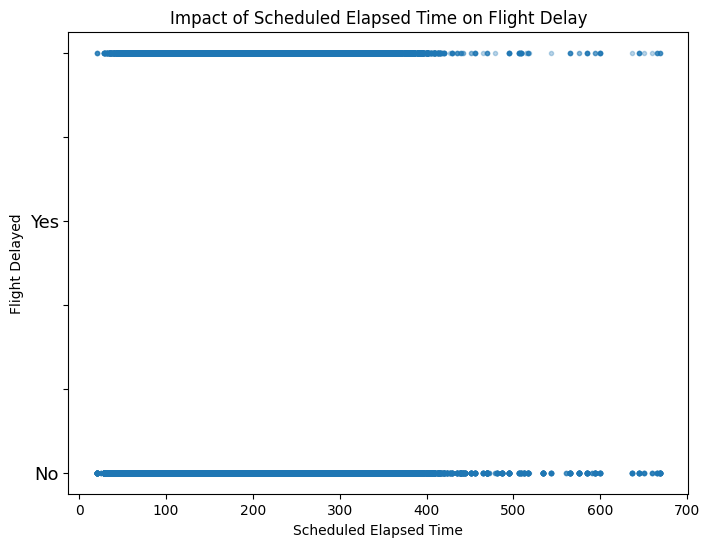

In [165]:
fig, ax = plt.subplots(figsize=(8, 6)) 
# 创建一个新的标签列，如果 'departure_delay' 大于 0，则标签为 1，否则为 0
train['delayed'] = (train['departure_delay'] > 0).astype(int)
plt.plot(train['scheduled_elapsed_time'], train['y'], '.', alpha = 0.3)
plt.xlabel('Scheduled Elapsed Time')
plt.ylabel('Flight Delayed')
ax.set_yticklabels(['', 'No','', '', 'Yes'], fontsize = 13 )
plt.title('Impact of Scheduled Elapsed Time on Flight Delay')
plt.show()


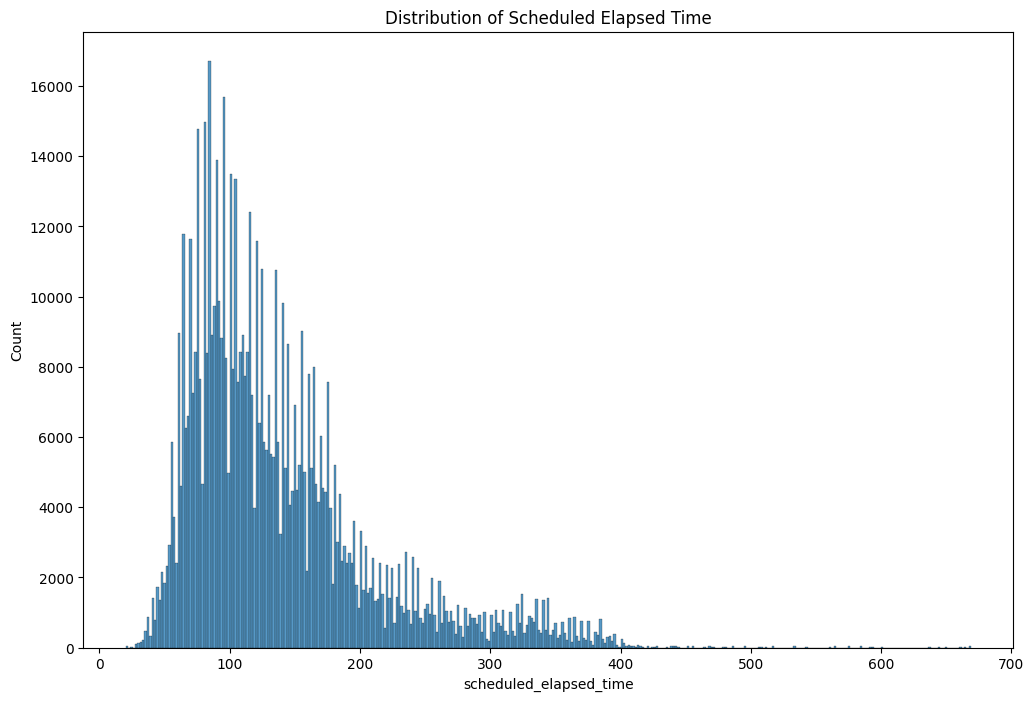

In [166]:
fig, ax = plt.subplots(figsize = (12, 8)) 
sns.histplot(train['scheduled_elapsed_time'])
plt.title('Distribution of Scheduled Elapsed Time')
plt.show()


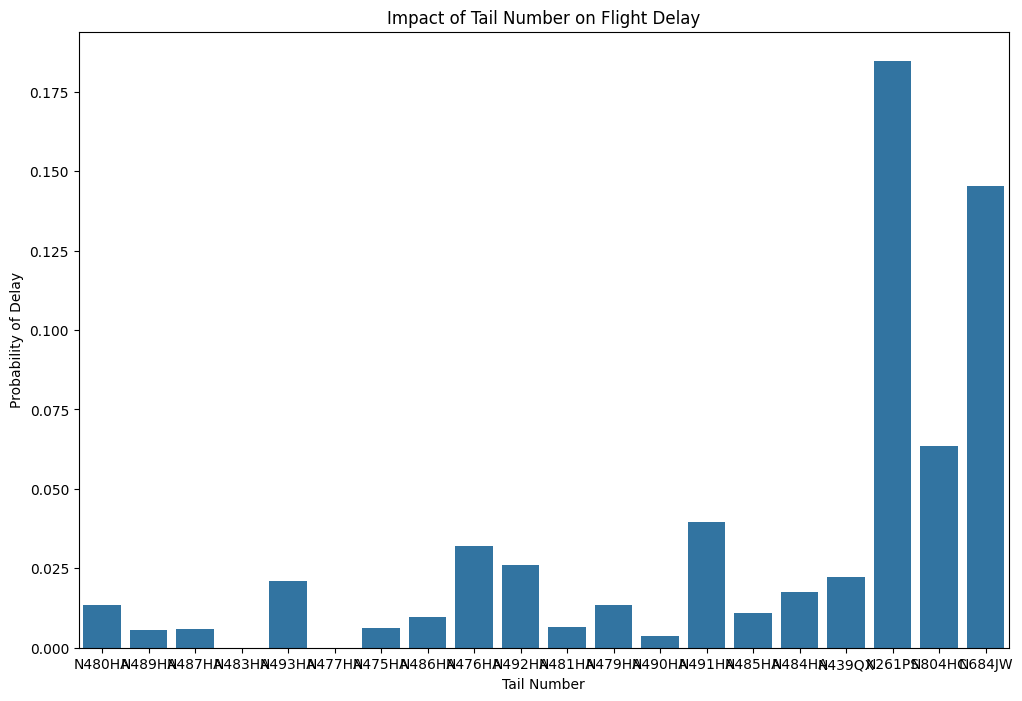

In [167]:
# Count the number of flights for each tail number
Plane_counts = train['tail_number'].value_counts()

# Get the 20 most common tail numbers
commonPlane = Plane_counts.iloc[:20].index

# Group the data by tail number
train_group = train.groupby('tail_number')

# Calculate the mean departure delay for each tail number
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x > 0)])

fig, ax = plt.subplots(figsize=(12, 8)) 

# Create a bar plot of the mean departure delay for the 20 most common tail numbers
sns.barplot(x=commonPlane, y=train_mean_delay.loc[commonPlane].values[:,0])

plt.xlabel('Tail Number')
plt.ylabel('Probability of Delay')
plt.title('Impact of Tail Number on Flight Delay')
plt.show()




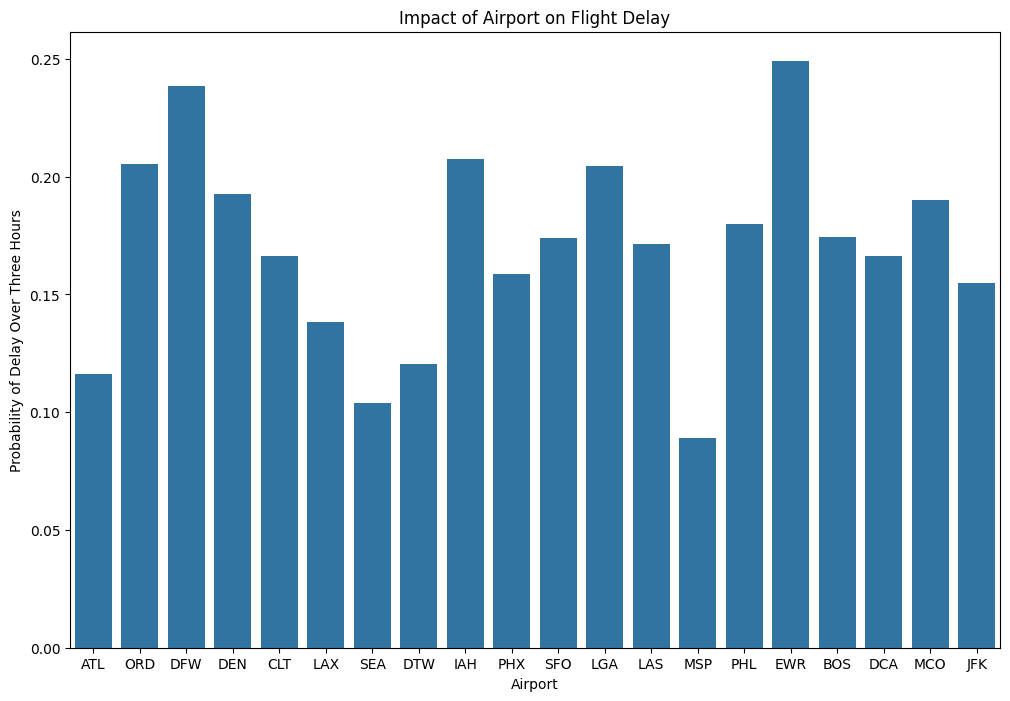

In [168]:
# Extract airport from 'airport_time_flight'
train['airport'] = train['airport_time_flight'].apply(lambda x: ast.literal_eval(x)[0])

# Count the number of flights for each airport
Airport_counts = train['airport'].value_counts()
Airport_counts = Airport_counts / sum(Airport_counts)

# Get the 20 most common airports
commonAirport = Airport_counts.iloc[:20].index

# Group the data by airport
train_group = train.groupby('airport')

# Calculate the mean delay for each airport
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

fig, ax = plt.subplots(figsize=(12, 8)) 

# Create a bar plot of the mean delay for the 20 most common airports
sns.barplot(x=commonAirport.astype(str), y=train_mean_delay.loc[commonAirport].values[:,0])

plt.xlabel('Airport')
plt.ylabel('Probability of Delay Over Three Hours')
plt.title('Impact of Airport on Flight Delay')
plt.show()


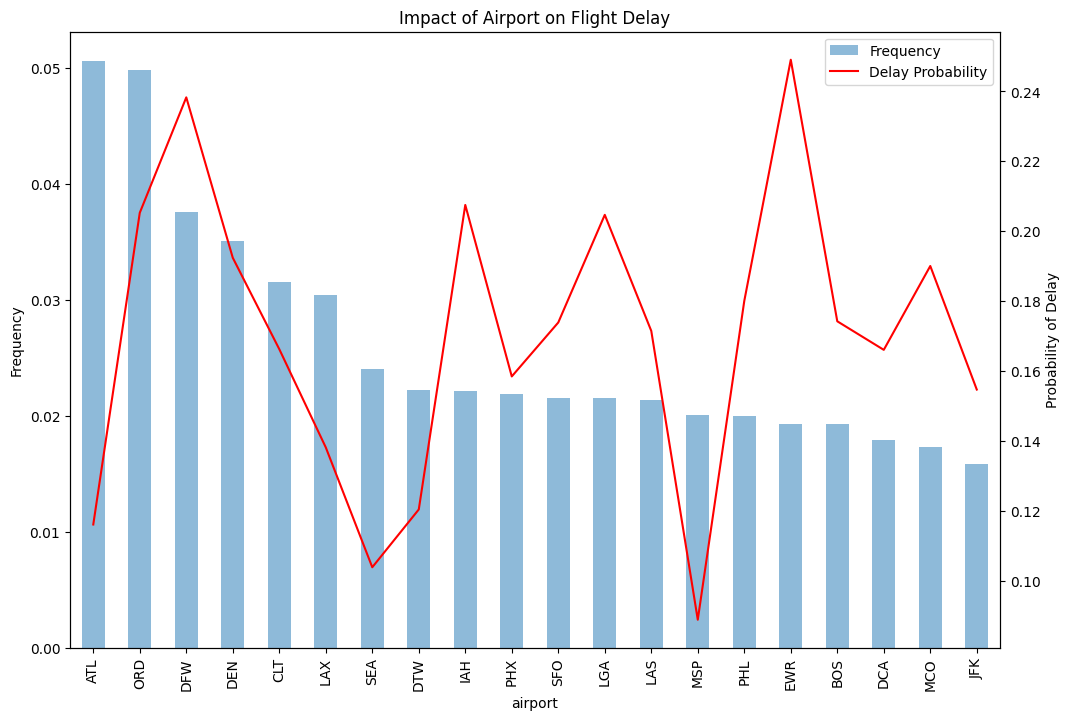

In [169]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()

# Plot the frequency of each airport
Airport_counts.loc[commonAirport].plot(kind='bar', ax=ax1, alpha=0.5)

# Plot the probability of delay over three hours for each airport
train_mean_delay.loc[commonAirport].plot(ax=ax2, color='r')

# “frequency”（频率）指的是每个机场出现的次数占总次数的比例。具体来说，如果一个机场在数据集中出现了100次，
# 而数据集总共有1000个样本，那么这个机场的频率就是100/1000=0.1。这是一种常见的统计度量，用于描述一个特定值在整个数据集中的相对频率。
ax1.set_ylabel('Frequency')
ax2.set_ylabel('Probability of Delay')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

labels1 = ['Frequency']
labels2 = ['Delay Probability']

plt.legend(handles1+handles2, labels1+labels2, loc='upper right')
plt.title('Impact of Airport on Flight Delay')
plt.show()


In [170]:
# 加一张图：只看航空公司因素导致的延误

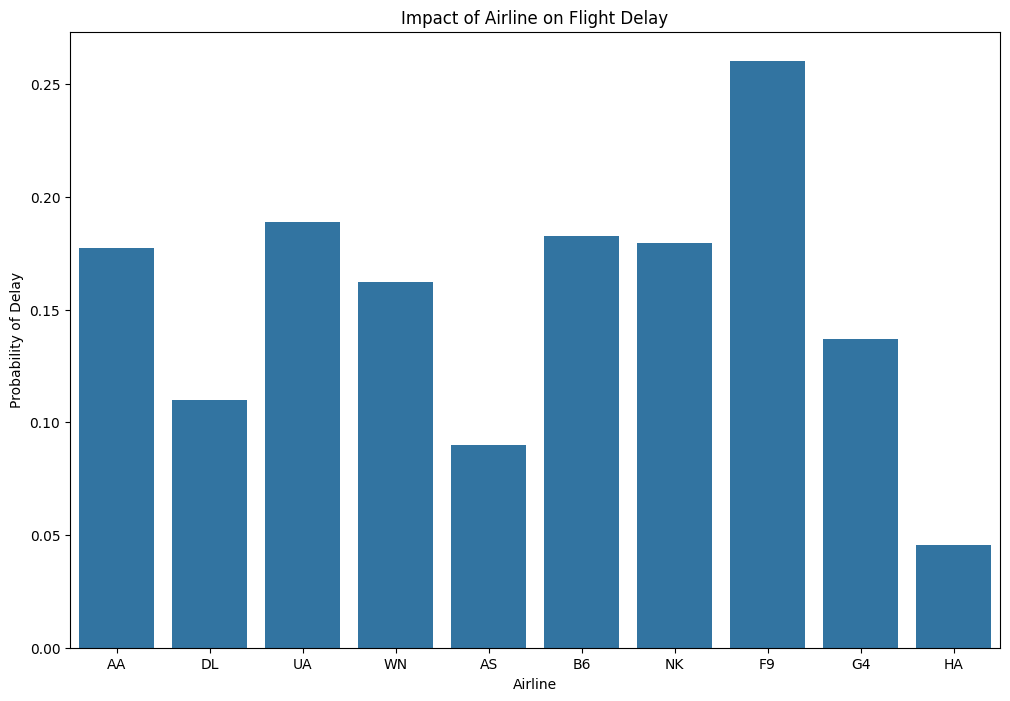

In [171]:
# Extract airport from 'airport_time_flight'
train['airline'] = train['carrier_code']

# Count the number of flights for each airport
Airport_counts = train['airline'].value_counts()
Airport_counts = Airport_counts / sum(Airport_counts)

# Get the 20 most common airports
commonAirport = Airport_counts.iloc[:20].index

# Group the data by airport
train_group = train.groupby('airline')

# Calculate the mean delay for each airport
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

fig, ax = plt.subplots(figsize=(12, 8)) 

# Create a bar plot of the mean delay for the 20 most common airports
sns.barplot(x=commonAirport.astype(str), y=train_mean_delay.loc[commonAirport].values[:,0])

plt.xlabel('Airline')
plt.ylabel('Probability of Delay')
plt.title('Impact of Airline on Flight Delay')
plt.show()


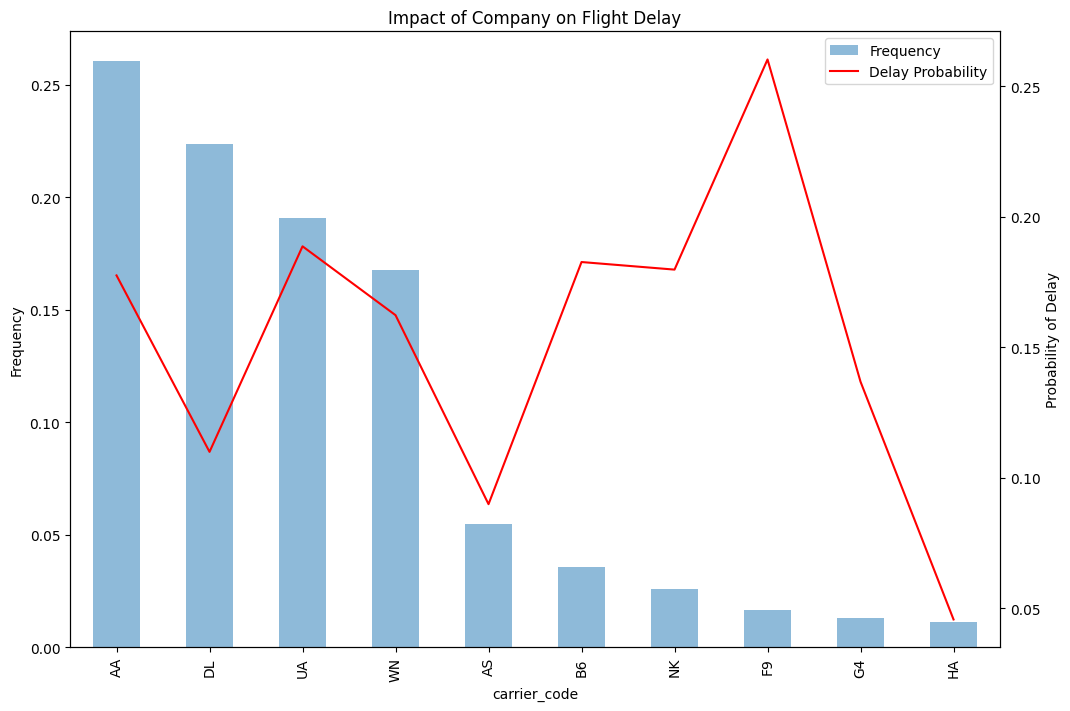

In [172]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax2 = ax1.twinx()

# Count the number of flights for each company
Company_counts = train['carrier_code'].value_counts()
Company_counts = Company_counts / sum(Company_counts)

# Get the most common companies
commonCompany = Company_counts.iloc[:20].index

# Group the data by company
train_group = train.groupby('carrier_code')

# Calculate the mean delay for each company
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

# Plot the frequency of each company
Company_counts.loc[commonCompany].plot(kind='bar', ax=ax1, alpha=0.5)

# Plot the probability of delay over three hours for each company
train_mean_delay.loc[commonCompany].plot(ax=ax2, color='r')

ax1.set_ylabel('Frequency')
ax2.set_ylabel('Probability of Delay')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

labels1 = ['Frequency']
labels2 = ['Delay Probability']

plt.legend(handles1+handles2, labels1+labels2, loc='upper right')
plt.title('Impact of Company on Flight Delay')
plt.show()


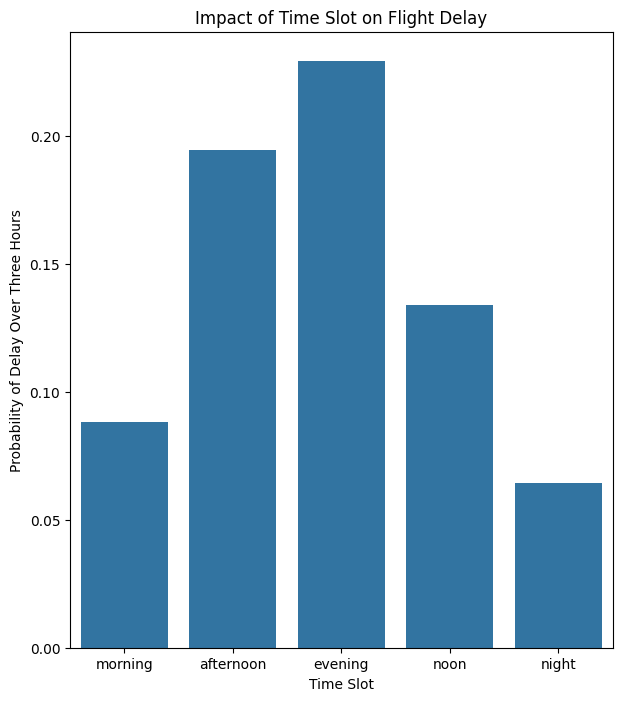

In [173]:
# Get the 20 most common time slots
commonTimeSlot = train['time slot'].value_counts().iloc[:20].index

# Group the data by time slot
train_group = train.groupby('time slot')

# Calculate the mean delay for each time slot
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

fig, ax = plt.subplots(figsize = (7, 8)) 

# Create a bar plot of the mean delay for the 20 most common time slots
sns.barplot(x=commonTimeSlot, y=train_mean_delay.loc[commonTimeSlot].values[:,0])

plt.xlabel('Time Slot')
plt.ylabel('Probability of Delay Over Three Hours')
plt.title('Impact of Time Slot on Flight Delay')
plt.show()


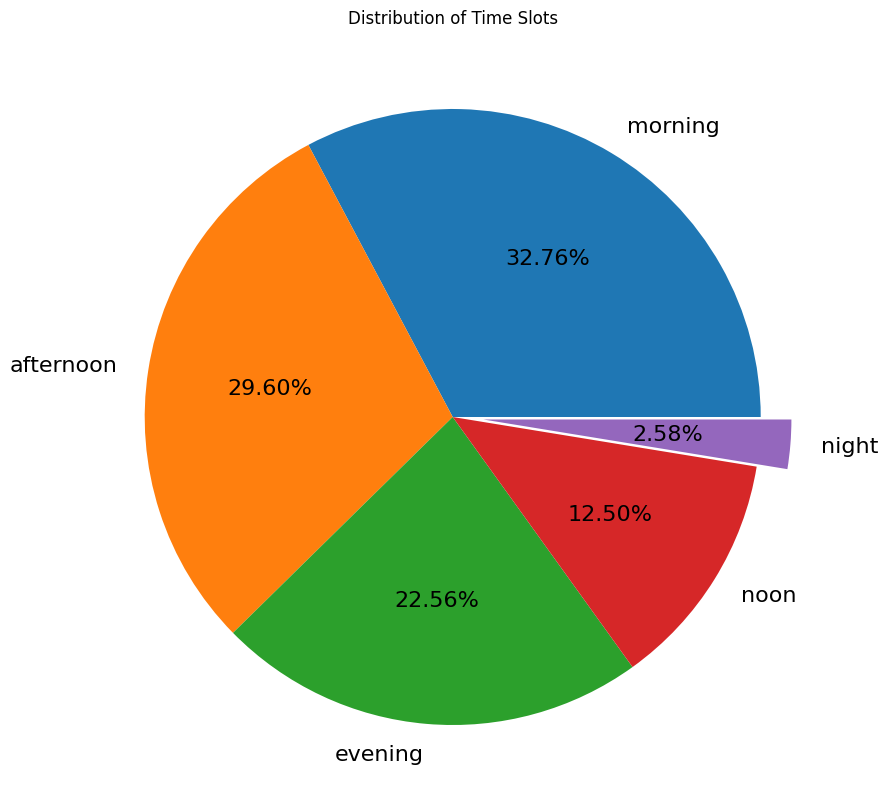

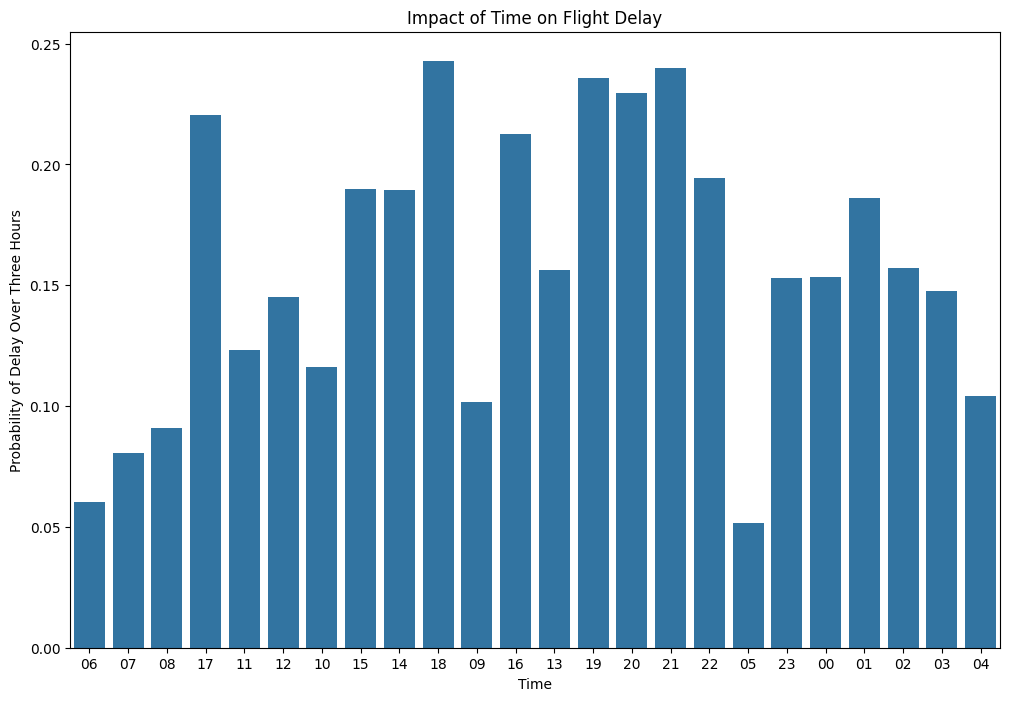

In [174]:
# Pie chart for time slot counts
Noon_count =  train['time slot'].value_counts()
fig, ax = plt.subplots(figsize=(10, 10)) 
exp = [0, 0, 0, 0, 0.1]
plt.pie(x=Noon_count.values, labels=Noon_count.index, explode=exp, 
        autopct="%0.2f%%", textprops={'fontsize':16})
plt.title('Distribution of Time Slots')
plt.show()

# Bar plot for delay probability by hour
commonHour = train['time'].value_counts().index
train_group = train.groupby('time')

# Calculate the mean delay for each hour
train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

fig, ax = plt.subplots(figsize = (12, 8)) 
sns.barplot(x=commonHour, y=train_mean_delay.loc[commonHour].values[:,0])
plt.xlabel('Time')
plt.ylabel('Probability of Delay Over Three Hours')
plt.title('Impact of Time on Flight Delay')
plt.show()


In [175]:
def weather_plot_draw(column_name):
    # Get the 20 most common values in the specified column
    common_values = train[column_name].value_counts().iloc[:20].index

    # Group the data by the specified column
    train_group = train.groupby(column_name)

    # Calculate the mean delay for each value in the specified column
    train_mean_delay = train_group['y'].agg([lambda x:np.mean(x)])

    fig, ax = plt.subplots(figsize = (15, 8)) 

    # Create a bar plot of the mean delay for the 20 most common values in the specified column
    sns.barplot(x=common_values, y=train_mean_delay.loc[common_values].values[:,0])

    plt.xlabel(column_name)
    plt.ylabel('Probability of Delay')
    plt.title('Impact of ' + column_name + ' on Flight Delay')
    plt.show()


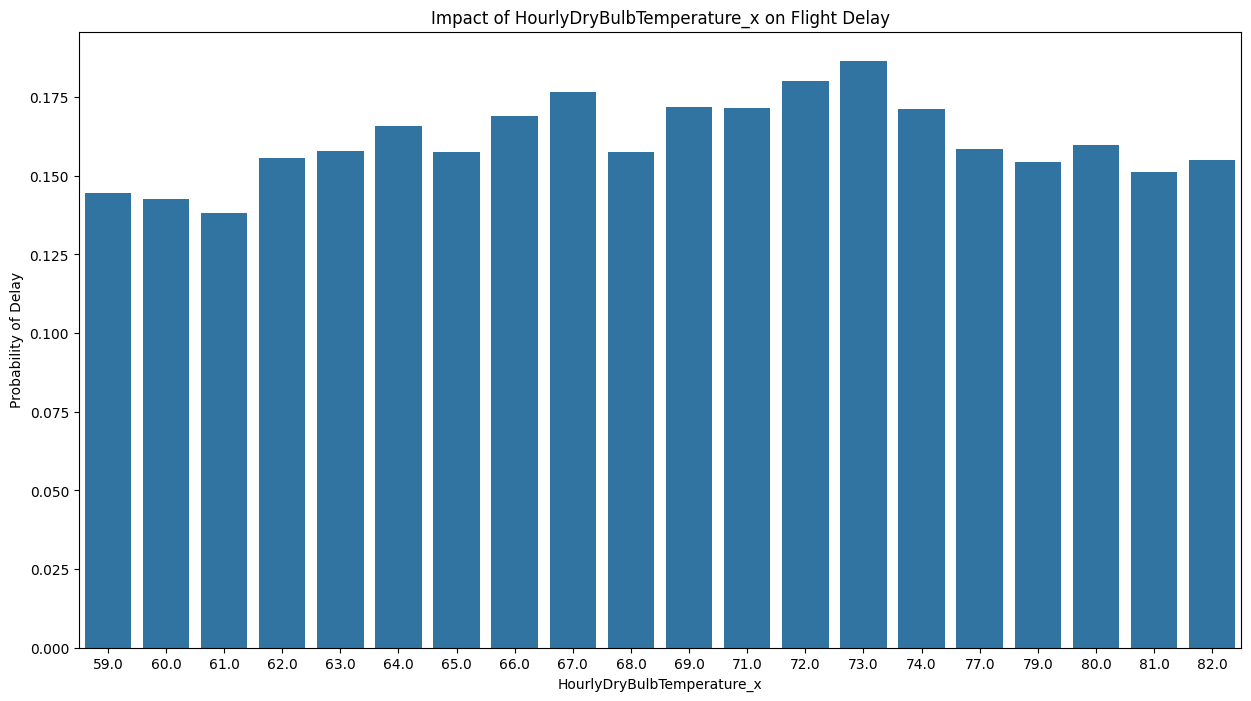

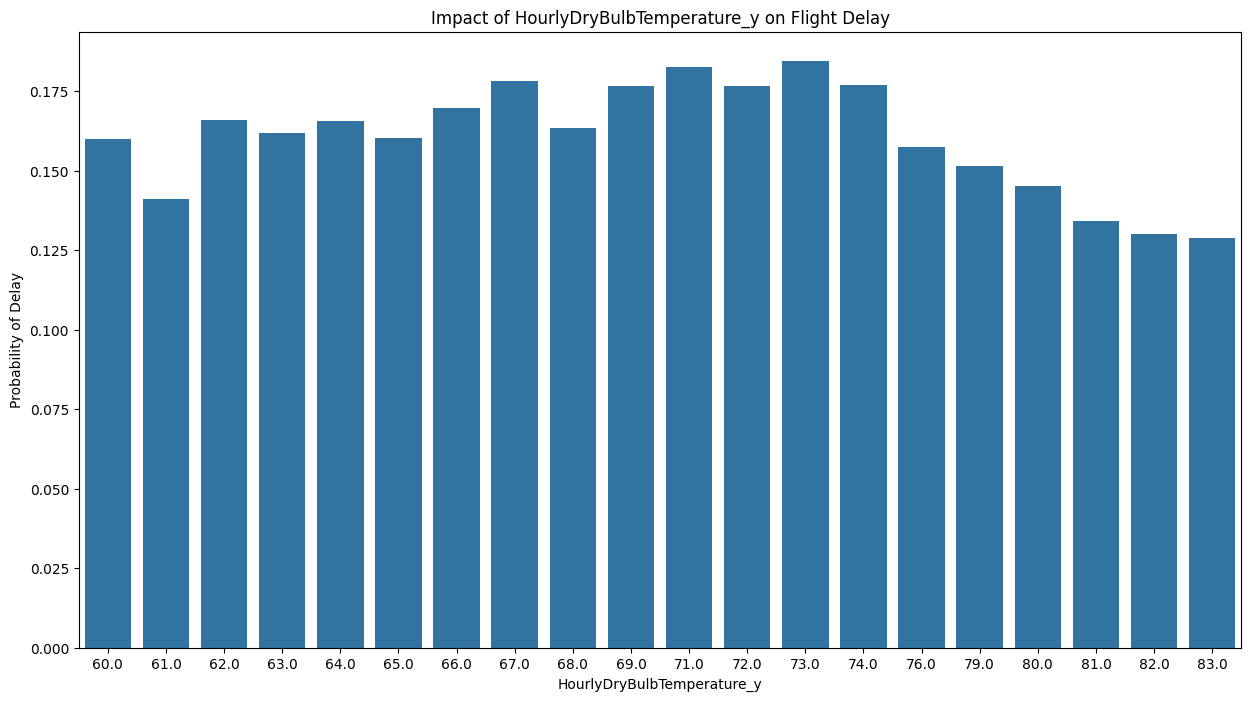

In [176]:
# tempreature
weather_plot_draw('HourlyDryBulbTemperature_x')
weather_plot_draw('HourlyDryBulbTemperature_y')

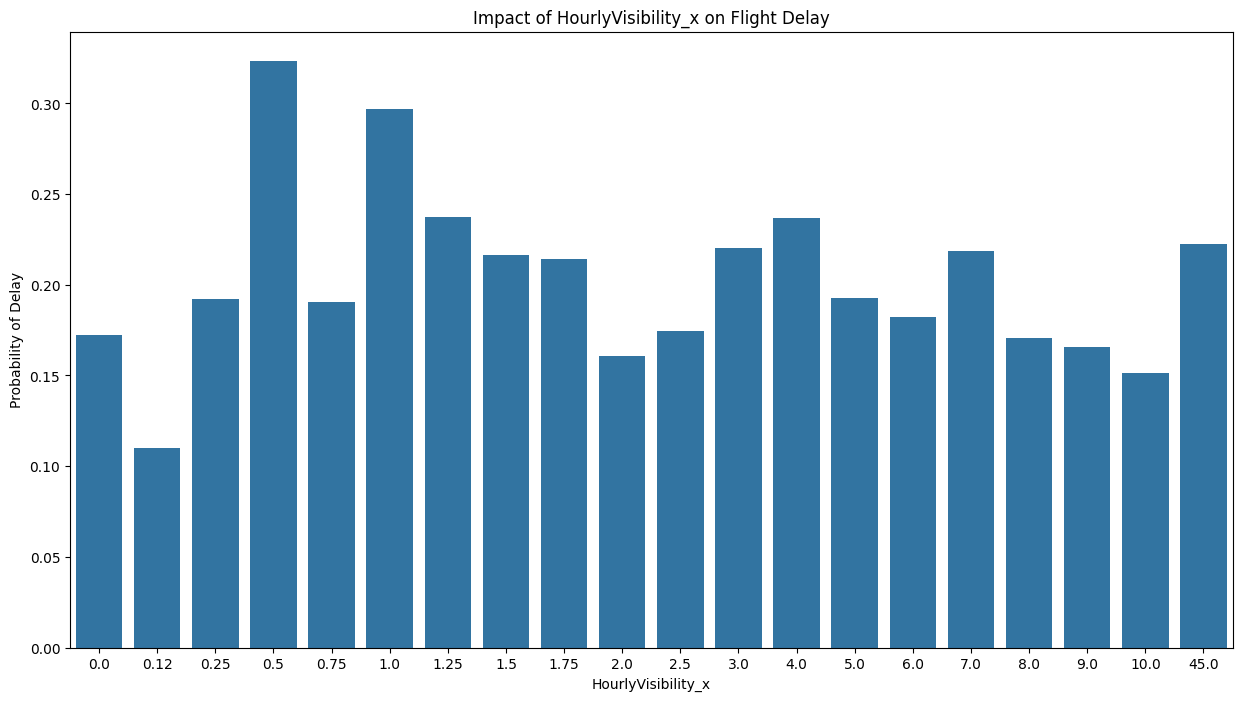

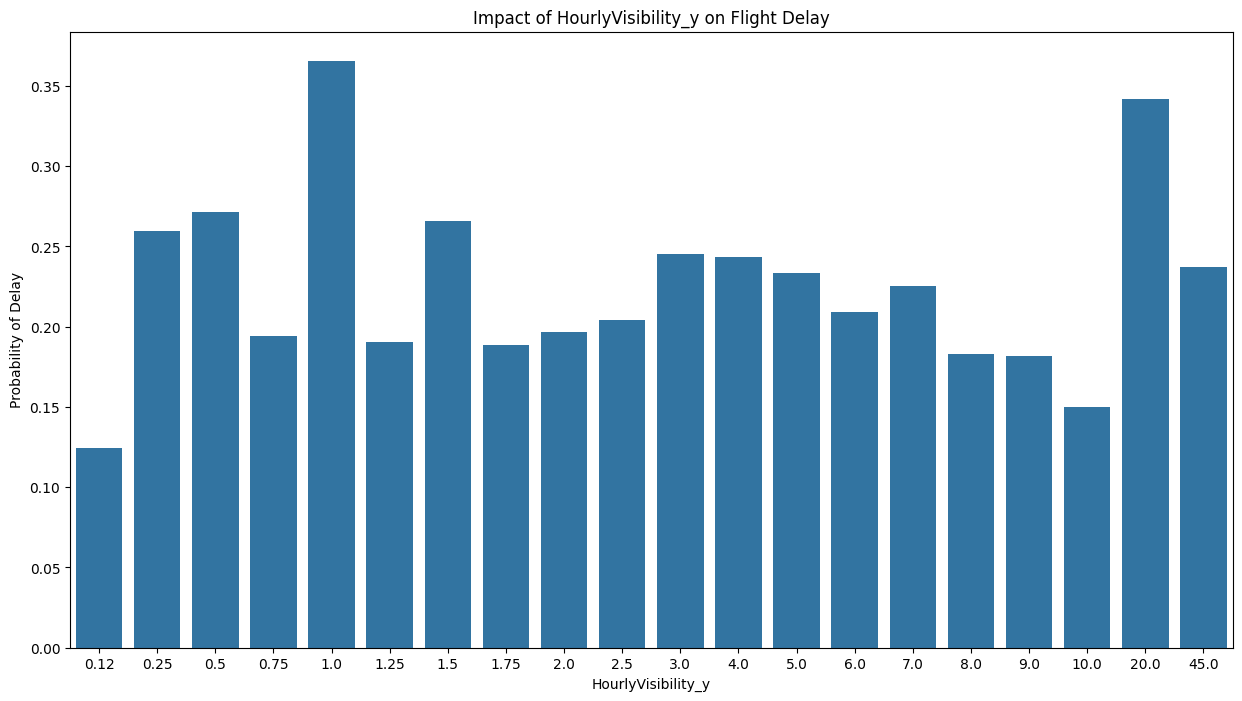

In [177]:
# visbility
weather_plot_draw('HourlyVisibility_x')
weather_plot_draw('HourlyVisibility_y')

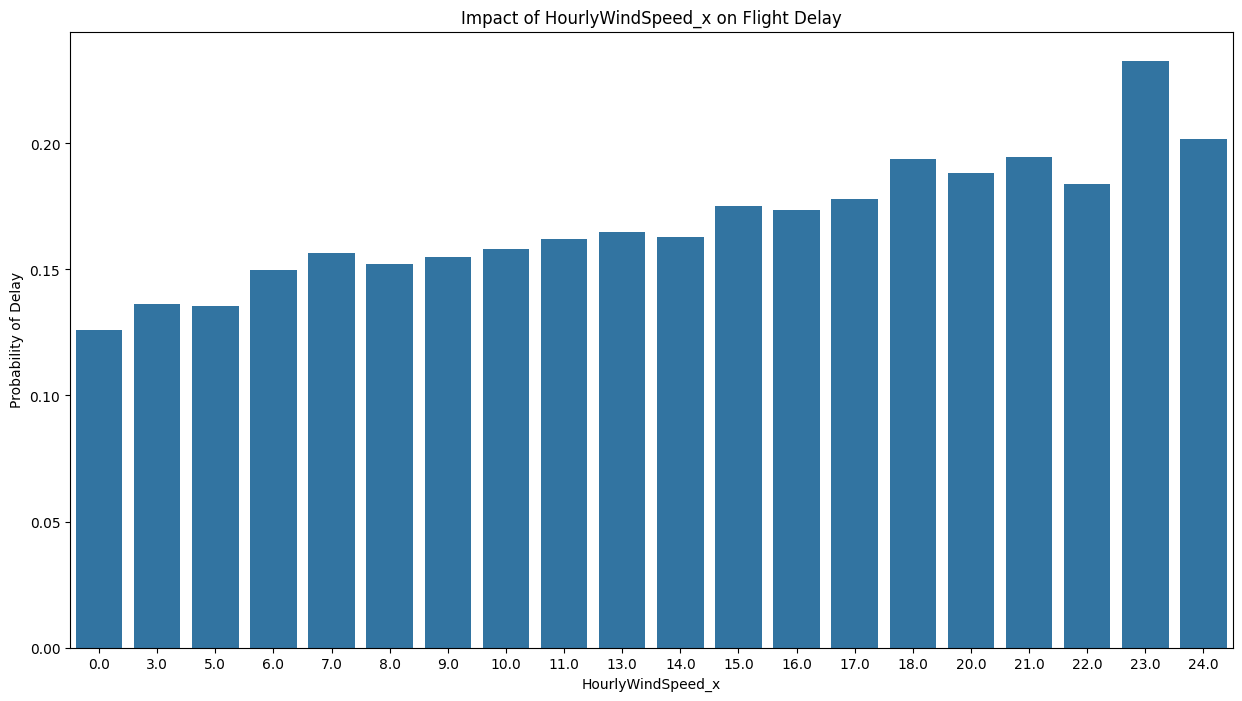

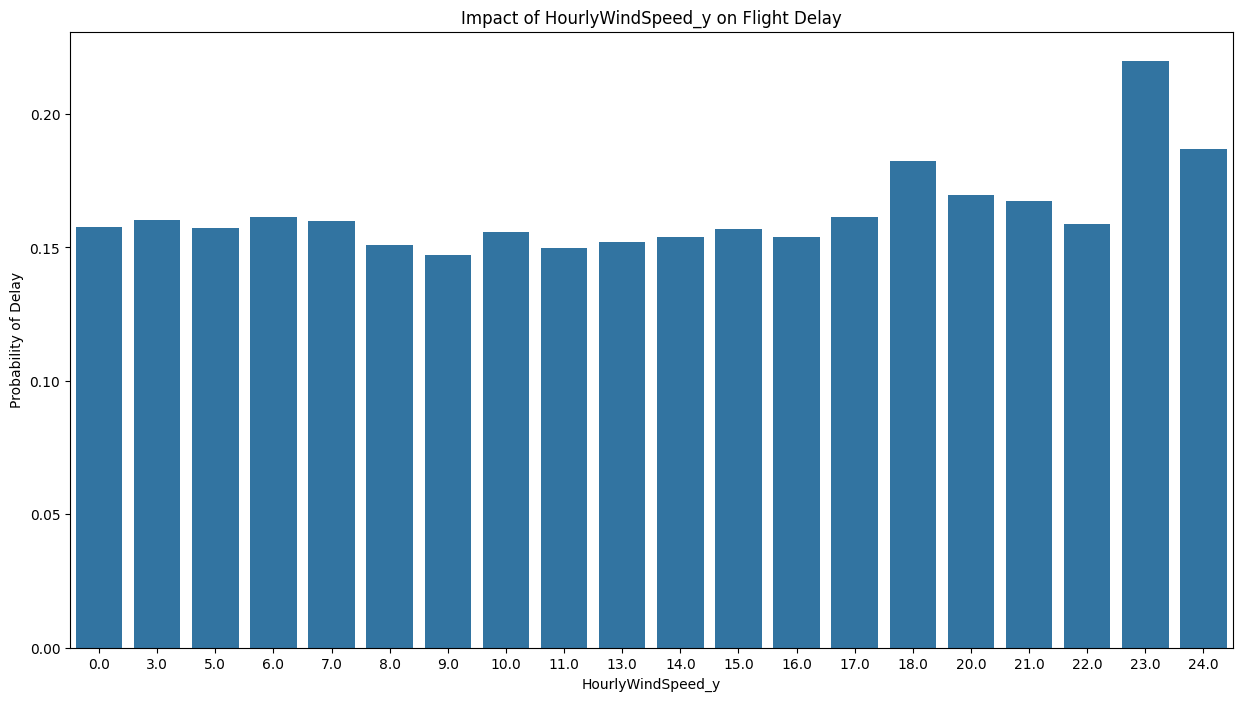

In [178]:
# wind speed
weather_plot_draw('HourlyWindSpeed_x')
weather_plot_draw('HourlyWindSpeed_y')

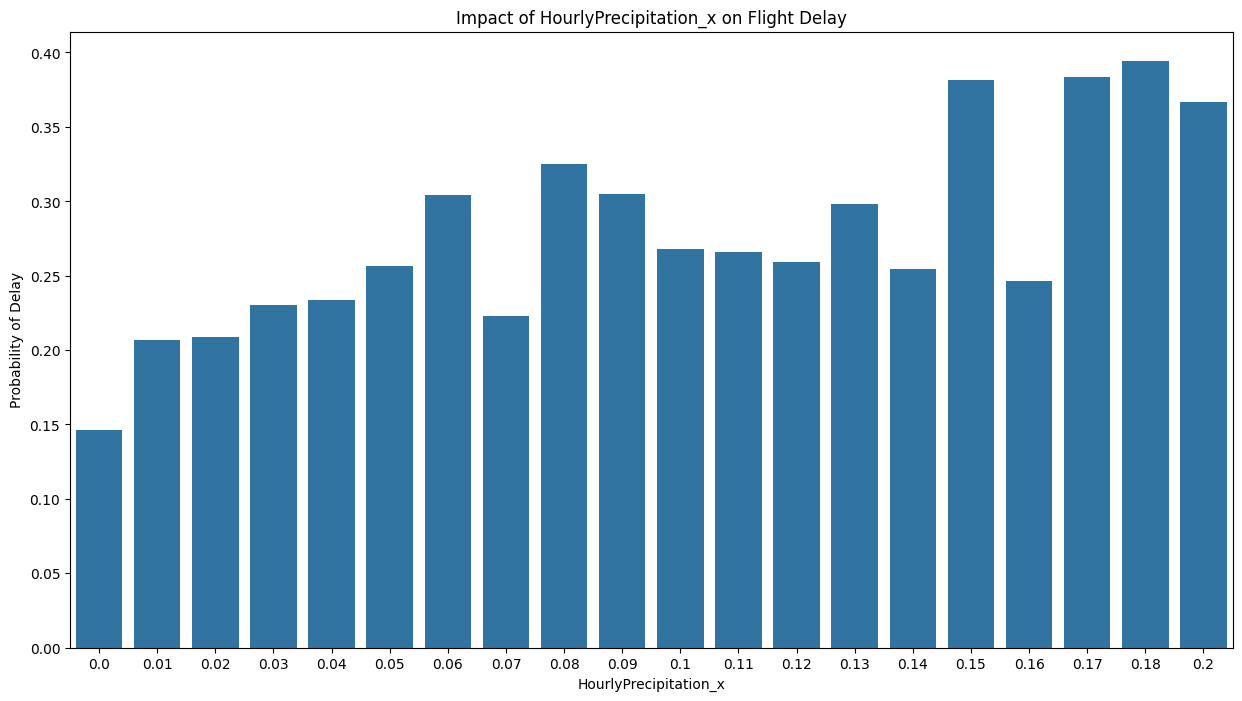

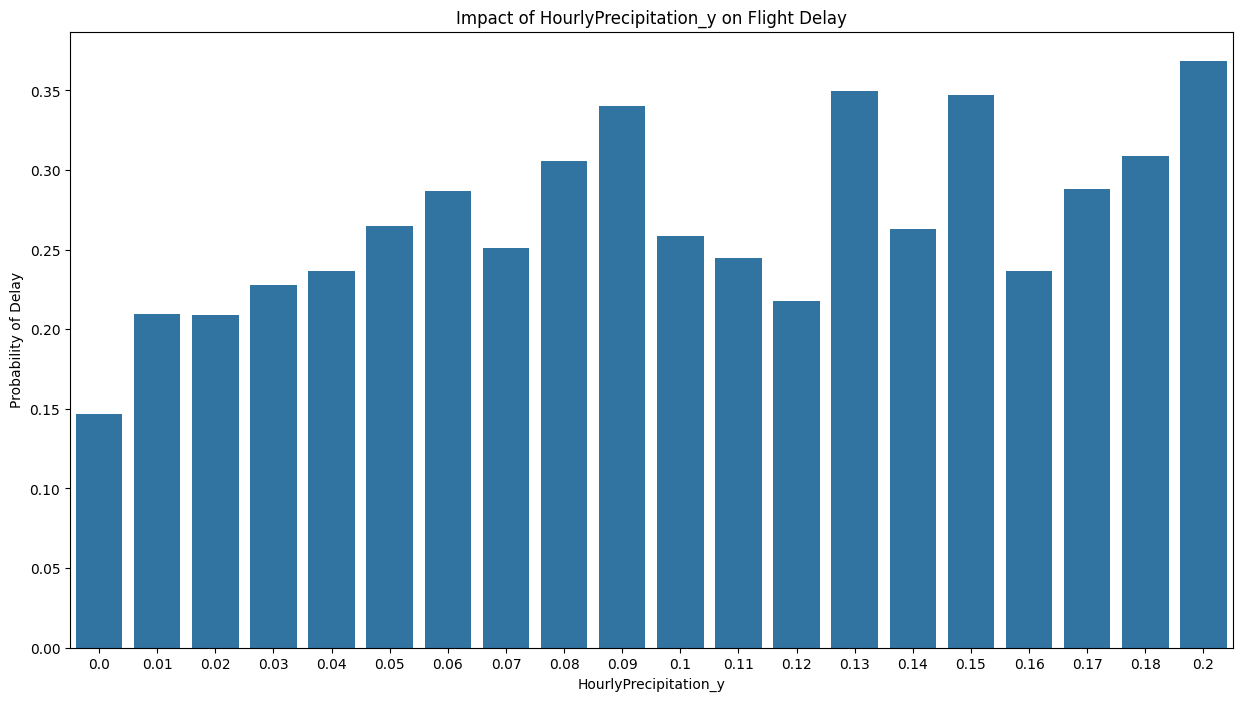

In [179]:
# Precipitation
weather_plot_draw('HourlyPrecipitation_x')
weather_plot_draw('HourlyPrecipitation_y')

In [180]:
train_last_col = ['tail_number', 'airport', 'carrier_code', 'time slot', 'HourlyPrecipitation_x', 'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
                  'HourlyPrecipitation_y', 'HourlyStationPressure_y', 'HourlyVisibility_y', 'HourlyWindSpeed_y', 
                  'scheduled_arrival_dt', 'departure_delay', 'y']

train_last = train.loc[:, train_last_col]
with open('train.pkl', 'wb') as file:
    pickle.dump(train_last, file)

In [181]:
# train model

In [182]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

# 定义类型变量和数值变量
# type_var 和 num_var 可以根据需求修改 （type_var是需要进行标签编码转换成float类型的）
type_var = ['carrier_code', 'airport', 'time slot', 'tail_number']
num_var = ['HourlyPrecipitation_x', 'HourlyStationPressure_x', 'HourlyVisibility_x', 'HourlyWindSpeed_x',
                  'HourlyPrecipitation_y', 'HourlyStationPressure_y', 'HourlyVisibility_y']

# 数据预处理
train = train.sort_values(by='scheduled_arrival_dt')
train.drop('scheduled_arrival_dt', axis=1, inplace=True)
train = train.dropna()

train = train[:45000]

# 标签编码
for var in type_var:
    le = preprocessing.LabelEncoder()
    le.fit(train[var])
    train[var] = le.transform(train[var])

# 划分训练集和测试集
train_ratio = 0.8
train_ = train.copy(deep=True)
train = train_.iloc[:int(train_.shape[0] * train_ratio), :]
test = train_.iloc[int(train_.shape[0] * train_ratio):, :]

# 分离特征和目标变量
train_x = train.drop('y', axis=1)
train_y = train['y']
test_x = test.drop('y', axis=1)
test_y = test['y']

# 定义验证函数
def val(model):
    model.fit(train_x, train_y)
    # 在二分类问题中，predict_proba 方法返回一个数组，其中包含两个概率值：第一个值表示样本属于负类的概率，第二个值表示样本属于正类的概率。
    # 通过选择第二个概率值（即正类别的概率），我们可以得到模型对正类别的预测概率。
    predict_value = model.predict_proba(test_x)[:, 1]
    predict_bool = predict_value > 0.5
    true_value = test_y.to_numpy()
    # 将一维数组转换为二维数组
    true_value_2d = true_value.reshape((-1, 1))
    predict_value_2d = predict_value.reshape((-1, 1))

    # 计算 AUC
    auc = roc_auc_score(true_value_2d, predict_value_2d)
    #auc = roc_auc_score(true_value, predict_value, multi_class='ovr')
    acc = precision_score(true_value, predict_bool)
    recall = recall_score(true_value, predict_bool)
    f1 = f1_score(true_value, predict_bool)
    return (auc, acc, recall, f1, predict_value)

# 定义字典存储测试结果
test_auc_dict = {}
test_acc_dict = {}
test_recall_dict = {}
test_f1_dict = {}
predict_value_dict = {}



In [183]:
# Create and train a Gradient Boosting Machine model
xgb_model = XGBClassifier()
xgb_model.fit(train_x, train_y)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(test_x)

# Evaluate the model
accuracy_xgb = accuracy_score(test_y, y_pred_xgb)
print(f'Gradient Boosting Accuracy: {accuracy_xgb}')

Gradient Boosting Accuracy: 0.9463333333333334


In [184]:
# 训练并验证随机森林模型
rf = RandomForestClassifier()
rf_auc, rf_acc, rf_recall, rf_f1, rf_predict_value = val(rf)

test_auc_dict['Random Forest'] = rf_auc
test_acc_dict['Random Forest'] = rf_acc
test_recall_dict['Random Forest'] = rf_recall
test_f1_dict['Random Forest'] = rf_f1
predict_value_dict['Random Forest'] = rf_predict_value
print('The auc score of rf is ' + str(round(rf_auc.mean(), 4)))


The auc score of rf is 0.9667


In [185]:

# 训练并验证GBM模型
gbc = GradientBoostingClassifier()
gbc_auc, gbc_acc, gbc_recall, gbc_f1, gbc_predict_value = val(gbc)

test_auc_dict['Gradient Boosting'] = gbc_auc
test_acc_dict['Gradient Boosting'] = gbc_acc
test_recall_dict['Gradient Boosting'] = gbc_recall
test_f1_dict['Gradient Boosting'] = gbc_f1
predict_value_dict['Gradient Boosting'] = gbc_predict_value
print('The auc score of gbc is ' + str(round(gbc_auc.mean(), 4)))


The auc score of gbc is 0.9703


In [187]:

# 比较模型性能

test_auc_df = pd.DataFrame(test_auc_dict, index = ['auc score'])
test_acc_df = pd.DataFrame(test_acc_dict, index = ['accuracy rate'])
test_recall_df = pd.DataFrame(test_recall_dict, index = ['recall rate'])
test_f1_df = pd.DataFrame(test_f1_dict, index = ['f1 score'])

result_df = pd.concat([test_auc_df, test_acc_df, test_recall_df, test_f1_df], axis = 0)
result_df.to_csv('model_compare.csv', index=True)


In [188]:
with open('predict_value.pkl', 'wb') as file:
    pickle.dump(predict_value_dict, file)
    
with open('true_value.pkl', 'wb') as file:
    pickle.dump(test_y.tolist(), file)